<div dir="ltr" align="center">

  <span style="font-size: 60px; color: #0B3C78; font-weight: 700;">
    Artificial Intelligence
  </span><br><br>

  <span style="font-size: 22px; color: #1F5FA8; font-weight: 500;">
    Computer Engineering Department
  </span><br>

  <span style="font-size: 20px; color: #1F5FA8; font-weight: 500;">
    Sharif University of Technology
  </span><br><br>

  <span style="font-size: 22px; color: #1F7A8C; font-weight: 600;">
    Spring 2026
  </span><br><br>

  <span style="font-size: 24px; color: #145DA0; font-weight: 700;">
    Practical Assignment
  </span><br><br>

  <span style="font-size: 22px; color: #3A7CC2; font-weight: 600;">
    Search Algorithms
  </span><br><br><br>

</div>

---

- Instructor: Dr.Tanghatari
- Practical Designer: Nima Kahderoonaei

---

### Student Information

- Name: Arvin
- Last Name: Baghal Asl
- Student Number: 403105793

---

### Instructions

- Make sure to:
  - Fill in your personal information above.
  - Run all the cells in the notebook and make sure your code runs truly 



# Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
from IPython.display import Image, display
from collections import deque
import heapq

# Uninformed Search

In this section, you will implement several well-known graph search algorithms on a complex maze.

You will begin by implementing Depth-First Search (DFS), followed by Breadth-First Search (BFS).

After that, you will implement Uniform Cost Search (UCS) and apply a heuristic to perform A* search on a weighted maze.

Several helper functions are provided to generate and visualize the maze. Do not modify the code in the cells below—only complete the sections marked with #TODO.

In [2]:
class Grid:
    def __init__(self, grid, grid_wheight):
        self.table = np.array(grid)
        self.table_weight = np.array(grid_wheight)
        self.start = None
        self.goal = None
        
    def set_start_pos(self, position):
        self.start = position
    
    def set_goal_pos(self, position):
        self.goal = position

    def get_cost(self, position):
        x, y = position
        return self.table_weight[x, y]
    
    def get_neighbors(self, position):
        x, y = position
        neighbors = []
        for dx, dy in [(1,0),(0,1), (-1,0), (0,-1)]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < self.table.shape[0] and 0 <= ny < self.table.shape[1] and self.table[nx, ny] == 1:
                neighbors.append((nx, ny))
        return neighbors
    
    
    def visualise_path(self, path=[], current=None, save_as=None, show_path=True):
        table_copy = self.table.copy()

        plt.figure(figsize=(6,6))
        plt.imshow(table_copy, cmap='coolwarm')
     
        if path and show_path:
            x_coords = [y  for (x, y) in path]
            y_coords = [x  for (x, y) in path]
            plt.plot(x_coords, y_coords, color="black", linewidth=2)
        if current:
            plt.scatter(current[1], current[0], color='black', s=575)
            
        plt.axis('off')
        if save_as:
            plt.savefig(save_as, bbox_inches='tight', pad_inches=0.05)
            plt.close()
        else:
            plt.show()
    
    def animate_explore(self, expand, frontiers=[], gif_name="maze_path.gif", fps=5):
        os.makedirs("frames", exist_ok=True)
        frame_files = []

        for step, p in enumerate(expand):
            filename = f"frames/frame_{step:03d}.png"
            self.visualise_path(expand[:step+1], current=p, save_as=filename)
            frame_files.append(filename)
        
        frames = [imageio.imread(f) for f in frame_files]
        imageio.mimsave(gif_name, frames, duration=1/fps)
        
        # Clean up
        for f in frame_files:
            os.remove(f)
        os.rmdir("frames")


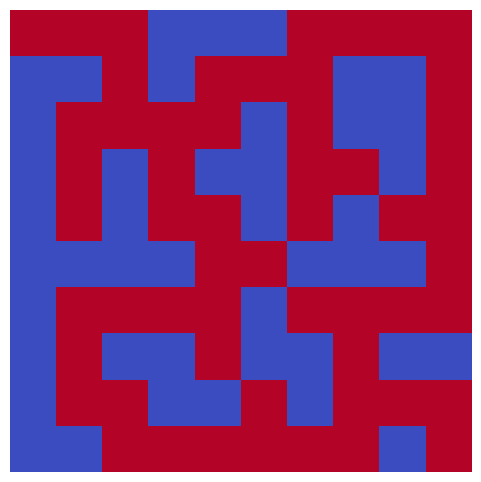

In [3]:
grid_data = [
    [1,1,1,0,0,0,1,1,1,1],
    [0,0,1,0,1,1,1,0,0,1],
    [0,1,1,1,1,0,1,0,0,1],
    [0,1,0,1,0,0,1,1,0,1],
    [0,1,0,1,1,0,1,0,1,1],
    [0,0,0,0,1,1,0,0,0,1],
    [0,1,1,1,1,0,1,1,1,1],
    [0,1,0,0,1,0,0,1,0,0],
    [0,1,1,0,0,1,0,1,1,1],
    [0,0,1,1,1,1,1,1,0,1],
]
grid_wheight_data = [
    [1,1,1,0,0,0,1,1,1,1],
    [0,0,1,0,1,1,1,0,0,1],
    [0,1,1,1,1,0,1,0,0,1],
    [0,1,0,1,0,0,1,4,0,1],
    [0,1,0,4,1,0,1,0,1,4],
    [0,0,0,0,4,1,0,0,0,1],
    [0,1,4,4,4,0,1,1,1,1],
    [0,4,0,0,1,0,0,1,0,0],
    [0,1,1,0,0,1,0,4,1,1],
    [0,0,1,4,4,1,1,1,0,1],
]

maze = Grid(grid_data, grid_wheight_data)
maze.set_start_pos((0,0))
maze.set_goal_pos((9,9))
maze.visualise_path()

# Depth-First Search (DFS)

In [4]:
def dfs(maze: Grid, start, goal):
	path = []
	explored = []

	def _dfs(current):
		explored.append(current)

		if current == goal:
			path.append(goal)
			return True
		
		for neighbor in maze.get_neighbors(current):
			if neighbor not in explored:
				if _dfs(neighbor):
					path.append(current)
					return True

		return False
	
	_dfs(start)

	path.reverse()

	return path, explored


C:\Users\HP\AppData\Local\Temp\ipykernel_18544\1236280877.py:57: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in frame_files]


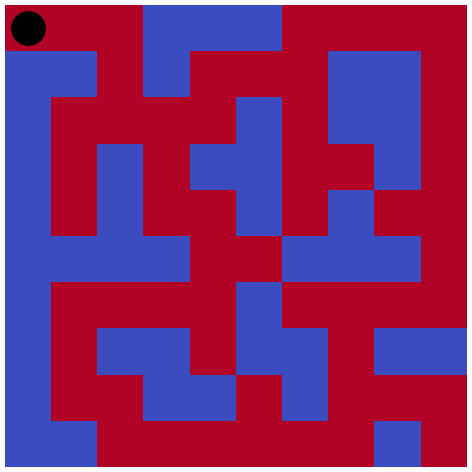

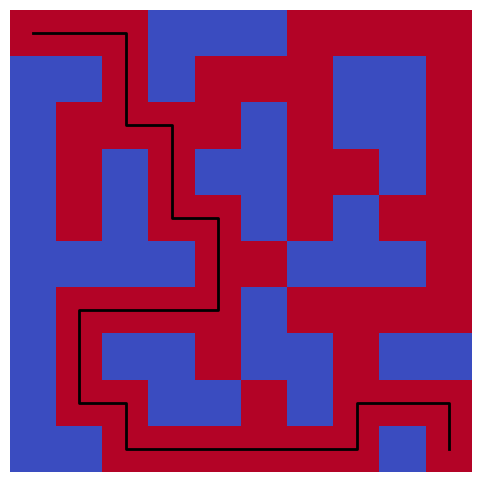

In [5]:
# visualizing dfs path and dfs expleration
dfs_path, dfs_explored = dfs(maze, start=maze.start, goal=maze.goal)
maze.animate_explore(dfs_explored, gif_name="dfs_explore.gif")
display(Image(filename="dfs_explore.gif"))
maze.visualise_path(dfs_path)

# Breadth-First Search

In [6]:
from collections import deque

def bfs(maze: Grid, start, goal):
	path = []
	explored = []
	parent = {}

	queue = deque([start])
	explored.append(start)
	parent[start] = None
	
	while queue:
		current = queue.popleft()

		if current == goal:
			break

		for neighbor in maze.get_neighbors(current):
			if neighbor not in explored:
				explored.append(neighbor)
				parent[neighbor] = current
				queue.append(neighbor)
				
	if goal in parent:
		node = goal
		while node is not None:
			path.append(node)
			node = parent[node]

		path.reverse()

	return path, explored


C:\Users\HP\AppData\Local\Temp\ipykernel_18544\1236280877.py:57: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in frame_files]


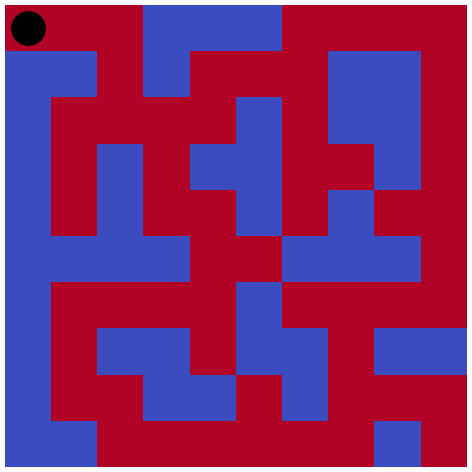

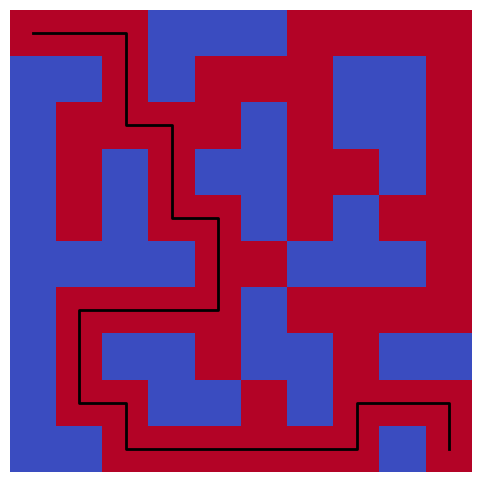

In [7]:
# visualizing bfs path and bfs expleration
bfs_path, bfs_explored = bfs(maze, start=maze.start, goal=maze.goal)
maze.animate_explore(bfs_explored, gif_name="bfs_explore.gif", fps=0.1)
display(Image(filename="bfs_explore.gif"))
maze.visualise_path(bfs_path)

# Weighted Search
Now assume that each square has an entrance cost (either 1 or 5 units).
You start at position (0, 0) and want to determine the minimum total cost required
to reach the goal.

First, implement Uniform Cost Search (UCS) to find the lowest-cost path.
Then, define an appropriate heuristic function and implement the A* algorithm.
Finally, compare the results of UCS and A* in terms of path cost and explored nodes.


# Uniform Cost Search

In [8]:
import heapq

def ucs(maze: Grid, start, goal):
	path = []
	explored = []
	parent = {}
	cost_so_far = {}

	#initialization
	frontier = []
	heapq.heappush(frontier, (0, start))
	parent[start] = None
	cost_so_far[start] = 0
	
	while frontier:
		cost, current = heapq.heappop(frontier)

		if current in explored:
			continue
		explored.append(current)

		if current == goal:
			break

		for neighbor in maze.get_neighbors(current):
			neighbor_cost = cost + maze.get_cost(neighbor)
			if neighbor not in cost_so_far or neighbor_cost < cost_so_far[neighbor]:
				cost_so_far[neighbor] = neighbor_cost
				parent[neighbor] = current
				heapq.heappush(frontier, (neighbor_cost, neighbor))
				
	if goal in parent:
		node = goal
		while node is not None:
			path.append(node)
			node = parent[node]

		path.reverse()

	return path, explored


C:\Users\HP\AppData\Local\Temp\ipykernel_18544\1236280877.py:57: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in frame_files]


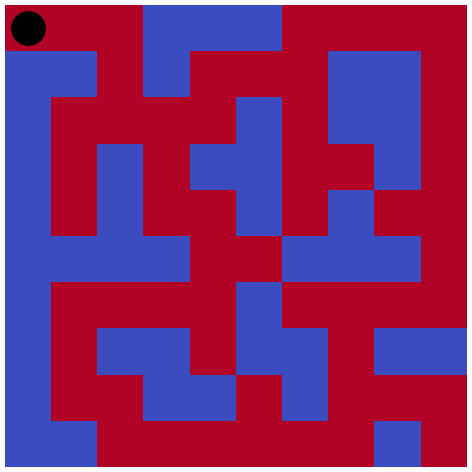

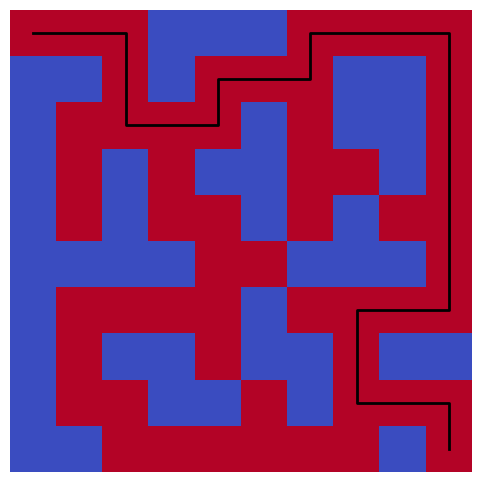

In [9]:
# visualizing A* path and ucs expleration
ucs_path, ucs_explored = ucs(maze, start=maze.start, goal=maze.goal)
maze.animate_explore(ucs_explored, gif_name="ucs_explore.gif")
display(Image(filename="ucs_explore.gif"))
maze.visualise_path(ucs_path)


# A* search

In [10]:
def heuristic(position, goal):
    # Manhattan distance
	value = abs(position[0] - goal[0]) + abs(position[1] - goal[1])
	return value


def a_star(maze, start, goal):
	path = []
	explored = []
	parent = {}
	g = {}

	#initialization
	frontier = []
	heapq.heappush(frontier, (0 + heuristic(start, goal), 0, start))
	parent[start] = None
	g[start] = 0
	
	while frontier:
		_, current_g, current = heapq.heappop(frontier)

		if current in explored:
			continue
		explored.append(current)

		if current == goal:
			break

		for neighbor in maze.get_neighbors(current):
			neighbor_g = current_g + maze.get_cost(neighbor)
			neighbor_f = neighbor_g + heuristic(neighbor, goal)
			if neighbor not in g or neighbor_g < g[neighbor]:
				g[neighbor] = neighbor_g
				parent[neighbor] = current
				heapq.heappush(frontier, (neighbor_f, neighbor_g, neighbor))
				
	if goal in parent:
		node = goal
		while node is not None:
			path.append(node)
			node = parent[node]

		path.reverse()
    
	return path, explored

C:\Users\HP\AppData\Local\Temp\ipykernel_18544\1236280877.py:57: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in frame_files]


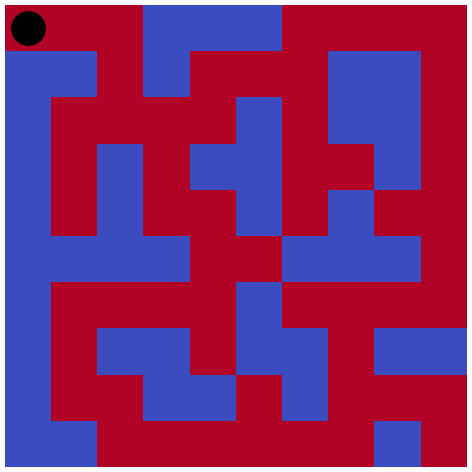

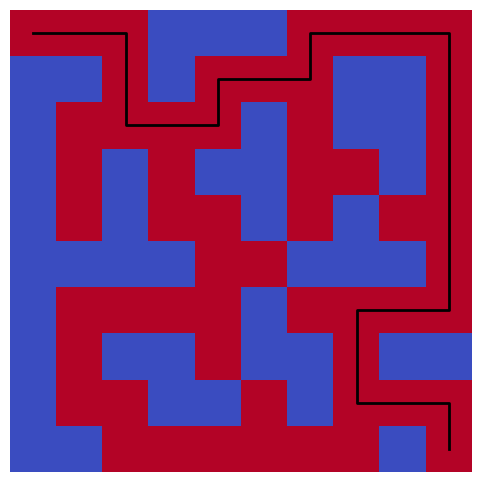

In [11]:
# visualizing A* path and ucs expleration
a_star_path, a_star_explored = a_star(maze, start=maze.start, goal=maze.goal)
maze.animate_explore(a_star_explored, gif_name="a_star_explore.gif")
display(Image(filename="a_star_explore.gif"))
maze.visualise_path(a_star_path)

# Question:

Explain about your heuristic function and why did you choose it?

I chose the **Manhattan distance** because it perfectly matches the movement rules of our maze. The agent can only move up, down, left, or right, never diagonally. The Manhattan heuristic counts the fewest orthogonal steps needed to reach the goal, assuming no obstacles. This makes it **admissible** – it never overestimates the true remaining cost, since every possible move costs at least 1 (and often more in a weighted grid). It is also **consistent**: moving from one cell to a neighbor changes the Manhattan distance by at most 1, which is never greater than the actual step cost. Because of these properties, A* with Manhattan distance is guaranteed to find the lowest‑cost path in our graph search.